# Task 3: Neural Surrogate, Architecture 1 of 4 (Deep MLP)

This is the first of four feed-forward architectures compared in Task 3. The Deep
MLP is the simplest one and it sets up the shared pipeline (data loading,
`log(x_H2_4)`-aware scaling, stratified train/val split, training loop, metrics,
parity plots) that the other notebooks (`NN_ResidualMLP.ipynb`,
`NN_MultiHead.ipynb`, `NN_PINN.ipynb`) import from `nn_utils.py`.

Architecture: 4 hidden layers, GELU + LayerNorm + Dropout, then a linear head to
15 outputs. The width, dropout, learning rate, weight_decay, and early-stop
patience are chosen by the hyperparameter sweep below (section 7). The winning
configuration becomes the shared default for the other 3 architectures.

Conventions (same as `EDA&ElasticNet.ipynb` and `XGBoost.ipynb`):
- 9 inputs, 15 modeled outputs; 4 deterministic outputs (`T3`, `P3`, `P4`, `MeOH_purity_stream4`) recovered by direct assignment.
- `x_H2_4` trained in log-space; the other 14 outputs are standardized only.
- 80/20 train/val split stratified on `n4_total == 0`, `random_state=42`.
- Test set (`dataset/test.csv`) is untouched until the final evaluation cells.

## 0. Install PyTorch (run once)

In [33]:
import subprocess, sys
for pkg in ["torch"]:
    try:
        __import__(pkg)
        print(f"{pkg} already installed")
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print("\n*** Restart the kernel before running the remaining cells. ***")

torch already installed


## 1. Imports and reproducibility

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

import nn_utils as nu
from nn_utils import (
    INPUT_COLS, OUTPUT_COLS, MODEL_OUTPUT_COLS, RANDOM_STATE,
    load_data, build_scaled_split, make_dataloaders,
    TrainConfig, train_model, predict_raw,
    regression_metrics_by_output, regime_diagnostics,
    assemble_full_prediction, parity_grid, save_checkpoint,
)

nu.seed_everything(RANDOM_STATE)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {device}")

torch 2.12.0+cpu | device: cpu


## 2. Load data

Same loading convention as `XGBoost.ipynb`: 9 inputs, 19 raw outputs (we model 15).

In [35]:
data = load_data("dataset")
print(f"Train : {len(data.X_train):>5} rows | {len(INPUT_COLS)} inputs | {len(OUTPUT_COLS)} outputs")
print(f"Test  : {len(data.X_test):>5} rows")
print(f"No-liquid rows — train: {data.no_liquid_train.sum()} | test: {data.no_liquid_test.sum()}")
print(f"\nModeled outputs ({len(MODEL_OUTPUT_COLS)}): {MODEL_OUTPUT_COLS}")

Train :  8000 rows | 9 inputs | 19 outputs
Test  :  2000 rows
No-liquid rows — train: 13 | test: 4

Modeled outputs (15): ['Q1_MW', 'Q2_MW', 'T_reactor_out', 'X_CO', 'n3_total', 'y_CO_3', 'y_H2_3', 'y_MeOH_3', 'y_H2O_3', 'n4_total', 'x_CO_4', 'x_H2_4', 'x_MeOH_4', 'x_H2O_4', 'MeOH_recovery']


## 3. Train/val split and scaling pipeline

Carve an 80/20 train/val split out of `train.csv`, stratified on the no-liquid
indicator. Fit `StandardScaler` on the training portion only. Targets pass
through `log` on `x_H2_4` first, then `StandardScaler` on the resulting
15-column matrix. See `nn_utils.TargetTransformer` for the exact transform.

In [36]:
scaled = build_scaled_split(data, val_size=0.2, seed=RANDOM_STATE)

print(f"Train fit : {len(scaled.train_idx):>5} rows | no-liquid: {scaled.no_liquid_train_fit.sum()}")
print(f"Val       : {len(scaled.val_idx):>5} rows | no-liquid: {scaled.no_liquid_val.sum()}")

Train fit :  6400 rows | no-liquid: 10
Val       :  1600 rows | no-liquid: 3


## 4. Deep MLP architecture

Four hidden blocks (`Linear, LayerNorm, GELU, Dropout`) followed by a linear
head. Width and dropout are arguments so the sweep below can vary them while
keeping the depth and the block pattern fixed.

In [37]:
class DeepMLP(nn.Module):
    def __init__(
        self,
        in_dim: int = len(INPUT_COLS),
        out_dim: int = len(MODEL_OUTPUT_COLS),
        hidden: int = 128,
        n_layers: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        layers = []
        prev = in_dim
        for _ in range(n_layers):
            layers += [
                nn.Linear(prev, hidden),
                nn.LayerNorm(hidden),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            prev = hidden
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Sanity check: instantiate the baseline and print its parameter count.
_baseline = DeepMLP()
print(_baseline)
print(f"\nTrainable parameters (hidden=128): {sum(p.numel() for p in _baseline.parameters() if p.requires_grad):,}")

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (14): GELU(approximate='none')
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=128, out_features=15, bias=True)
  )
)

Trainable parameters (hidden=128): 53,775


## 5. Hyperparameter sweep (all rounds completed)

Four rounds of sweeping were run to find the best Deep MLP configuration.
All previous configs (A to I) are kept as comments in the code cell for
reference. The final round isolated the effect of depth by sweeping
`n_layers` in {2, 3, 4, 6, 8} with all other E_aggressive hyperparameters fixed.

### Round history

| Round | Configs | Key finding |
|-------|---------|-------------|
| 1 | A to E (hidden in {128, 192}) | A_baseline won (val 0.0608); wider was worse |
| 2 | D/E with hidden=64, +F | E_aggressive won (val 0.0511); smaller was better |
| 3 | G (hidden=32), H/I (hidden=48) | hidden=64 still wins; going smaller hurts |
| 4 (depth) | E_2L to E_8L (n_layers sweep) | n_layers=4 wins; shallower and deeper both worse |

### Depth sweep (round 4)

All E_aggressive hyperparameters fixed: lr=3e-4, wd=5e-4, dropout=0.20,
hidden=64, ES patience=40, max_epochs=1000.

| Config | n_layers | Result |
|--------|----------|--------|
| E_2L   | 2        | worse than E_4L |
| E_3L   | 3        | worse than E_4L |
| E_4L   | 4        | winner, val 0.05111, test R²=0.9827 |
| E_6L   | 6        | worse than E_4L |
| E_8L   | 8        | worse than E_4L |

Conclusion: n_layers=4 is best at hidden=64. Only E_4L is left active
in the sweep code; all others are commented out.

In [ ]:
sweep_configs = [
    # --- Previous rounds commented out (kept for reference) ---
    # Round 1
    # {"name": "A_baseline",            "lr": 1e-3, "wd": 1e-5, "dropout": 0.10, "hidden": 128, "n_layers": 4, "es_p": 20},
    # {"name": "B_more_reg",            "lr": 1e-3, "wd": 1e-4, "dropout": 0.15, "hidden": 128, "n_layers": 4, "es_p": 30},
    # {"name": "C_lower_lr",            "lr": 5e-4, "wd": 1e-5, "dropout": 0.10, "hidden": 128, "n_layers": 4, "es_p": 30},
    # {"name": "D_thiner_combo",        "lr": 5e-4, "wd": 1e-4, "dropout": 0.15, "hidden":  64, "n_layers": 4, "es_p": 40},
    # {"name": "E_aggressive",          "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden":  192, "n_layers": 4, "es_p": 40},
    # --- Round 2 ---
    # {"name": "E_aggressive",          "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden":  64, "n_layers": 4, "es_p": 40},
    # {"name": "F_baseline_low_hidden", "lr": 1e-3, "wd": 1e-5, "dropout": 0.10, "hidden":  64, "n_layers": 4, "es_p": 20},
    # # --- Round 3 ---
    # {"name": "G_hidden_32",           "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden":  32, "n_layers": 4, "es_p": 40, "max_epochs": 1000},
    # {"name": "H_hidden_48",           "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden":  48, "n_layers": 4, "es_p": 40, "max_epochs": 1000},
    # {"name": "I_deeper_48",           "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden":  48, "n_layers": 6, "es_p": 40, "max_epochs": 1000},

    # --- n_layers sweep (all E_aggressive params, only depth varies) ---
    #{"name": "E_2L", "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden": 64, "n_layers": 2, "es_p": 40, "max_epochs": 1000},
   # {"name": "E_3L", "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden": 64, "n_layers": 3, "es_p": 40, "max_epochs": 1000},
    {"name": "E_4L", "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden": 64, "n_layers": 4, "es_p": 40, "max_epochs": 1000},  # original E_aggressive
    #{"name": "E_6L", "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden": 64, "n_layers": 6, "es_p": 40, "max_epochs": 1000},
    #{"name": "E_8L", "lr": 3e-4, "wd": 5e-4, "dropout": 0.20, "hidden": 64, "n_layers": 8, "es_p": 40, "max_epochs": 1000},
]

sweep_models = {}
sweep_histories = {}
sweep_results = []

for cfg in sweep_configs:
    n_layers = cfg.get("n_layers", 4)
    max_epochs = cfg.get("max_epochs", 500)
    print(f"\n=== {cfg['name']}: lr={cfg['lr']:.0e}, wd={cfg['wd']:.0e}, "
          f"dropout={cfg['dropout']}, hidden={cfg['hidden']}, n_layers={n_layers}, "
          f"ES patience={cfg['es_p']}, max_epochs={max_epochs} ===")
    nu.seed_everything(RANDOM_STATE)
    candidate = DeepMLP(hidden=cfg["hidden"], n_layers=n_layers, dropout=cfg["dropout"])
    n_params = sum(p.numel() for p in candidate.parameters() if p.requires_grad)
    train_loader, val_loader = make_dataloaders(scaled, batch_size=128, seed=RANDOM_STATE)
    cand_config = TrainConfig(
        max_epochs=max_epochs,
        lr=cfg["lr"],
        weight_decay=cfg["wd"],
        lr_factor=0.5,
        lr_patience=10,
        early_stopping_patience=cfg["es_p"],
        grad_clip_norm=1.0,
        device=device,
        log_every=100,
    )
    hist = train_model(candidate, train_loader, val_loader, config=cand_config)

    # Cheap test-R² readout, used only to break ties / sanity-check.
    pred_mod = predict_raw(candidate, scaled.X_test_s, scaled.Y_transformer, device=device)
    pred_full = assemble_full_prediction(pred_mod, data.X_test)
    m = regression_metrics_by_output(data.y_test, pred_full, OUTPUT_COLS)
    test_r2 = m["R2"].mean(skipna=True)

    sweep_models[cfg["name"]] = candidate
    sweep_histories[cfg["name"]] = hist
    sweep_results.append({
        "name":          cfg["name"],
        "params":        n_params,
        "best_val_loss": hist.best_val_loss,
        "best_epoch":    hist.best_epoch,
        "epochs_run":    len(hist.val_loss),
        "test_R2":       test_r2,
    })
    print(f"  → best val {hist.best_val_loss:.5f} @ epoch {hist.best_epoch} | test R²={test_r2:.5f}")

sweep_df = pd.DataFrame(sweep_results).sort_values("best_val_loss").reset_index(drop=True)
print("\nSweep results (sorted by best val loss):")
print(sweep_df.round(5).to_string(index=False))

## 6. Sweep diagnostics: loss curves per config

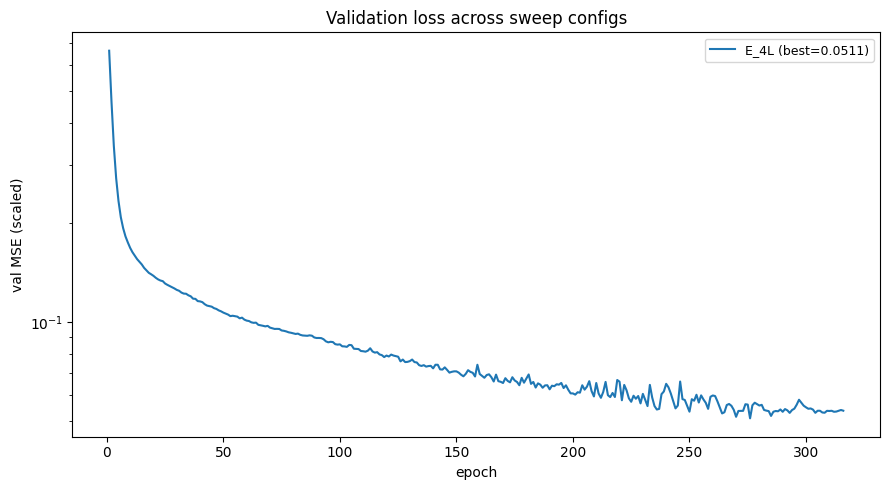

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
for cfg in sweep_configs:
    hist = sweep_histories[cfg["name"]]
    epochs = np.arange(1, len(hist.val_loss) + 1)
    ax.plot(epochs, hist.val_loss, label=f"{cfg['name']} (best={hist.best_val_loss:.4f})")
ax.set_xlabel("epoch"); ax.set_ylabel("val MSE (scaled)")
ax.set_yscale("log"); ax.set_title("Validation loss across sweep configs")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 7. Select winner and adopt as the final Deep MLP

The lowest val-loss configuration is taken as the final model. Its trained
weights and history are exposed as `model` and `history` so the rest of the
notebook (test evaluation, parity plots, checkpoint) treats it as the final
Deep MLP.

In [40]:
winner_name = sweep_df.iloc[0]["name"]
winner_cfg = next(c for c in sweep_configs if c["name"] == winner_name)
model = sweep_models[winner_name]
history = sweep_histories[winner_name]

print(f"Winner: {winner_name}")
print(f"  hyperparameters: lr={winner_cfg['lr']:.0e}, wd={winner_cfg['wd']:.0e}, "
      f"dropout={winner_cfg['dropout']}, hidden={winner_cfg['hidden']}, ES patience={winner_cfg['es_p']}")
print(f"  best val loss : {history.best_val_loss:.5f} at epoch {history.best_epoch}")
print(f"  trained epochs: {len(history.val_loss)}")
print(f"  parameters    : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Winner: E_4L
  hyperparameters: lr=3e-04, wd=5e-04, dropout=0.2, hidden=64, ES patience=40
  best val loss : 0.05111 at epoch 276
  trained epochs: 316
  parameters    : 14,607


## 8. Final training curves (winner only)

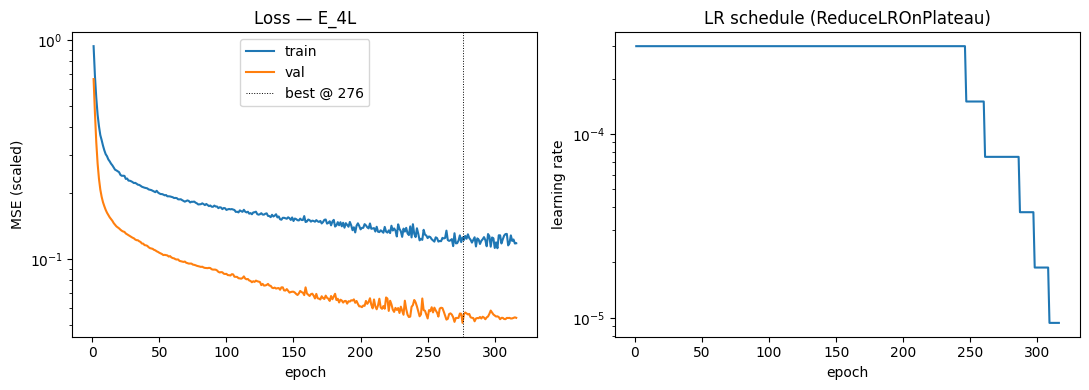

In [41]:
fig, (ax_loss, ax_lr) = plt.subplots(1, 2, figsize=(11, 4))
epochs = np.arange(1, len(history.train_loss) + 1)
ax_loss.plot(epochs, history.train_loss, label="train")
ax_loss.plot(epochs, history.val_loss, label="val")
ax_loss.axvline(history.best_epoch, color="k", lw=0.7, ls=":", label=f"best @ {history.best_epoch}")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("MSE (scaled)")
ax_loss.set_yscale("log"); ax_loss.set_title(f"Loss — {winner_name}"); ax_loss.legend()

ax_lr.plot(epochs, history.lr)
ax_lr.set_xlabel("epoch"); ax_lr.set_ylabel("learning rate")
ax_lr.set_yscale("log"); ax_lr.set_title("LR schedule (ReduceLROnPlateau)")
plt.tight_layout(); plt.show()

## 9. Test-set evaluation

Predict the held-out `test.csv`, invert the target transform, then recover
the 4 deterministic outputs (`T3`, `P3`, `P4`, `MeOH_purity_stream4`) so the
metric tables are directly comparable with the EN/XGBoost reports.

In [42]:
test_pred_modeled = predict_raw(model, scaled.X_test_s, scaled.Y_transformer, device=device)
test_pred_full = assemble_full_prediction(test_pred_modeled, data.X_test)

dmlp_test_per_output = regression_metrics_by_output(
    data.y_test, test_pred_full, OUTPUT_COLS
).sort_values("RMSE", ascending=False)

print("Deep MLP — test per-output metrics (sorted by RMSE, worst first):")
dmlp_test_per_output.round(5)

Deep MLP — test per-output metrics (sorted by RMSE, worst first):


,output,RMSE,MAE,R2
6,n3_total,30.44669,22.93051,0.98236
12,n4_total,2.68394,2.02384,0.98590
2,T_reactor_out,1.17463,0.85674,0.98073
0,Q1_MW,0.06792,0.05239,0.98011
15,x_MeOH_4,0.03003,0.01104,0.96220
18,MeOH_purity_stream4,0.03003,0.01104,0.96220
17,MeOH_recovery,0.01708,0.01107,0.99101
16,x_H2O_4,0.01608,0.01018,0.98889
8,y_H2_3,0.00597,0.00443,0.99118
7,y_CO_3,0.00583,0.00431,0.99157


## 10. Aggregate test metrics

In [43]:
dmlp_m = regression_metrics_by_output(data.y_test, test_pred_full, OUTPUT_COLS)
print(
    f"Deep MLP test — "
    f"RMSE: {dmlp_m['RMSE'].mean():.5f} | "
    f"MAE: {dmlp_m['MAE'].mean():.5f} | "
    f"R²: {dmlp_m['R2'].mean(skipna=True):.5f}"
)

Deep MLP test — RMSE: 1.81498 | MAE: 1.36422 | R²: 0.98270


## 11. Regime diagnostics (all / liquid / no-liquid)

In [44]:
dmlp_test_diagnostics = regime_diagnostics(
    data.y_test, test_pred_full, data.no_liquid_test, columns=OUTPUT_COLS
)
dmlp_test_diagnostics.round(5)

,group,rows,mean_RMSE,mean_MAE,mean_R2
0,all_rows,2000,1.81498,1.36422,0.98270
1,liquid_rows,1996,1.81472,1.36547,0.98589
2,no_liquid_rows,4,0.87055,0.73936,0.41010


## 12. Comparison vs Task 2 baselines

Elastic Net and XGBoost test aggregates are taken from the respective notebook
runs (`EDA&ElasticNet.ipynb`, `XGBoost.ipynb`) and reproduced in `AGENT_NOTES.md`.

In [45]:
elastic_net_test = {"RMSE": 0.657, "MAE": 0.486, "R2": 0.938}
xgboost_test     = {"RMSE": 0.289, "MAE": 0.224, "R2": 0.987}
dmlp_test_agg = {
    "RMSE": dmlp_m["RMSE"].mean(),
    "MAE":  dmlp_m["MAE"].mean(),
    "R2":   dmlp_m["R2"].mean(skipna=True),
}

comparison = pd.DataFrame({
    "Elastic Net (test)": elastic_net_test,
    "XGBoost (test)":     xgboost_test,
    "Deep MLP (test)":    dmlp_test_agg,
}).T
comparison["RMSE_vs_XGB"] = comparison["RMSE"] - xgboost_test["RMSE"]
comparison["R2_vs_XGB"]   = comparison["R2"]   - xgboost_test["R2"]

print("Aggregate test comparison:")
comparison.round(5)

Aggregate test comparison:


,RMSE,MAE,R2,RMSE_vs_XGB,R2_vs_XGB
Elastic Net (test),0.65700,0.48600,0.9380,0.36800,-0.0490
XGBoost (test),0.28900,0.22400,0.9870,0.00000,0.0000
Deep MLP (test),1.81498,1.36422,0.9827,1.52598,-0.0043


In [46]:
# Per-output R² for the outputs previously identified as weakest under EN and XGBoost.
weak_outputs = ["y_H2O_3", "Q2_MW", "MeOH_recovery", "x_H2_4", "x_CO_4", "x_MeOH_4"]
en_weak  = {"y_H2O_3": 0.752, "Q2_MW": 0.836, "MeOH_recovery": 0.858}
xgb_weak = {"y_H2O_3": 0.994, "Q2_MW": 0.989, "MeOH_recovery": 0.998,
            "x_H2_4": 0.890, "x_CO_4": 0.963, "x_MeOH_4": 0.962}

dmlp_weak = dmlp_test_per_output.set_index("output")["R2"].loc[weak_outputs].to_dict()

weak_comparison = pd.DataFrame({
    "Elastic Net R²": en_weak,
    "XGBoost R²":     xgb_weak,
    "Deep MLP R²":    dmlp_weak,
}).T

print("Per-output R² on previously-weak outputs:")
weak_comparison.round(4)

Per-output R² on previously-weak outputs:


,y_H2O_3,Q2_MW,MeOH_recovery,x_H2_4,x_CO_4,x_MeOH_4
Elastic Net R²,0.752,0.8360,0.858,NaN,NaN,NaN
XGBoost R²,0.994,0.9890,0.998,0.890,0.9630,0.9620
Deep MLP R²,0.987,0.9767,0.991,0.942,0.9771,0.9622


## 13. Parity plots

Full 19-output parity grid. Train predictions on validation-fold rows only
(the model hasn't seen those during training); test predictions on the entire
held-out test set.

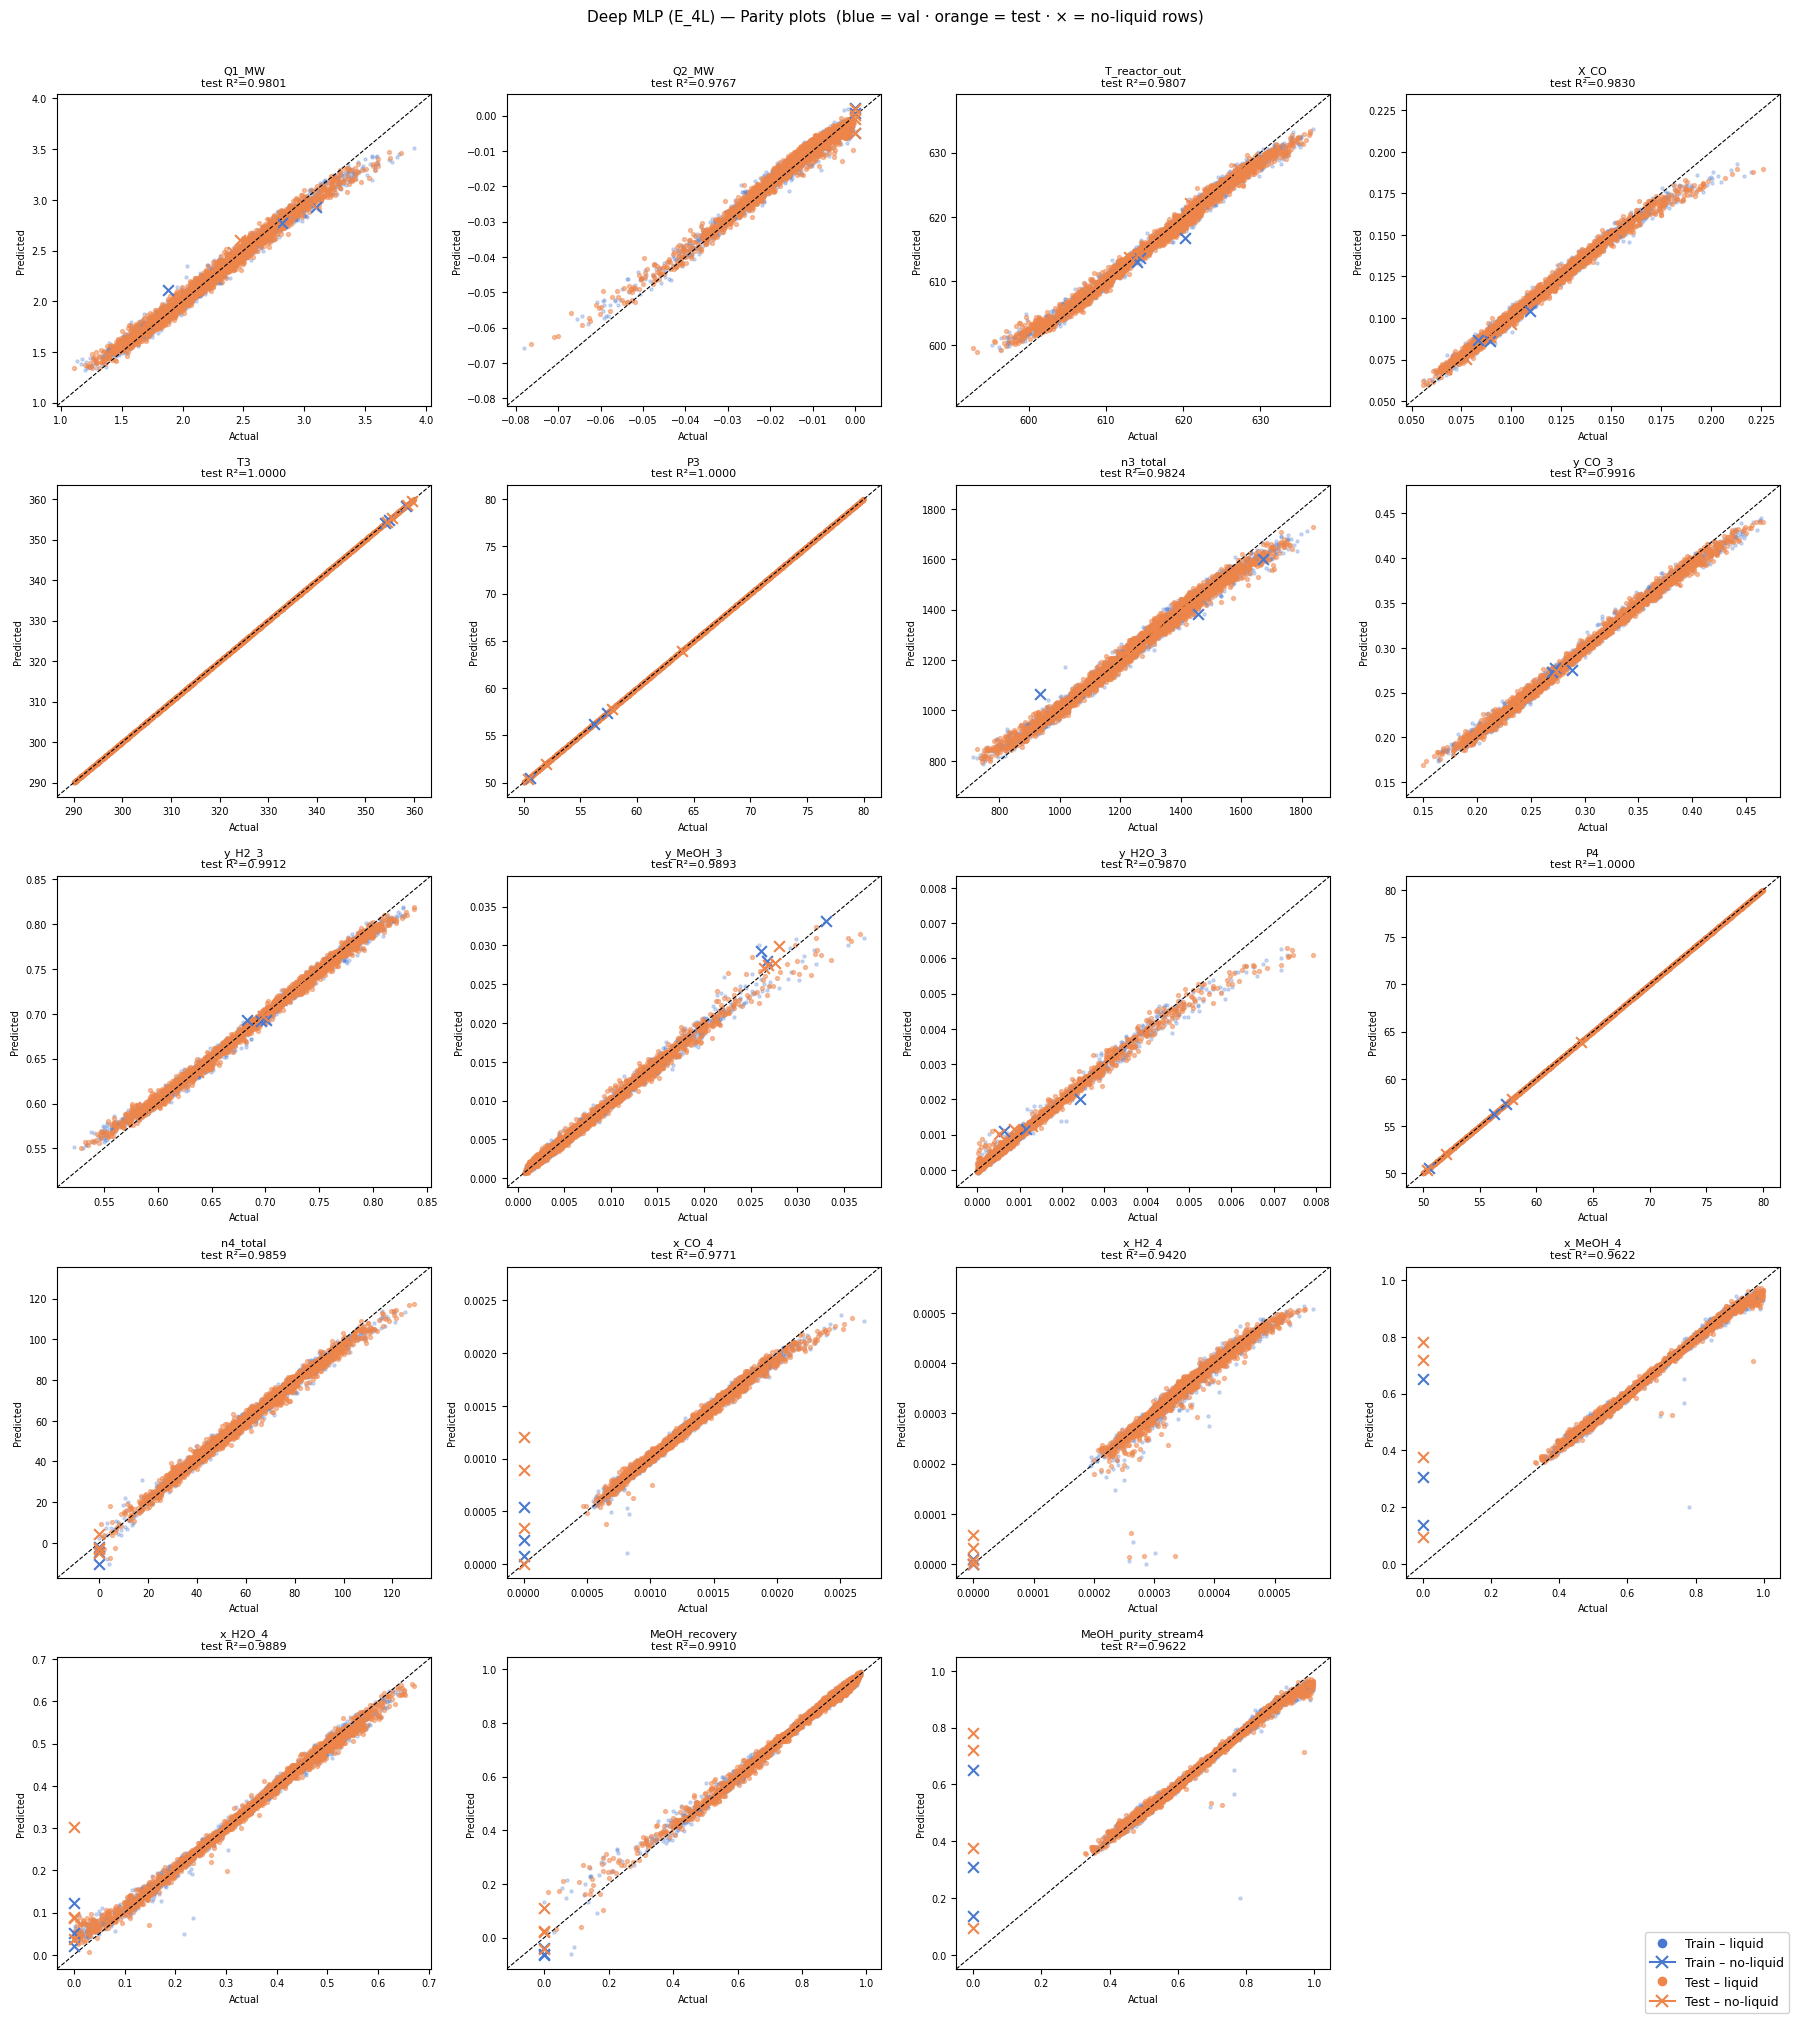

In [47]:
val_pred_modeled = predict_raw(model, scaled.X_val_s, scaled.Y_transformer, device=device)
val_pred_full = assemble_full_prediction(val_pred_modeled, data.X_train.iloc[scaled.val_idx])
y_val_true = data.y_train.iloc[scaled.val_idx]
no_liquid_val_series = data.no_liquid_train.iloc[scaled.val_idx]

fig = parity_grid(
    y_train_true=y_val_true,
    y_train_pred=val_pred_full,
    y_test_true=data.y_test,
    y_test_pred=test_pred_full,
    no_liquid_train=no_liquid_val_series,
    no_liquid_test=data.no_liquid_test,
    columns=OUTPUT_COLS,
    title=f"Deep MLP ({winner_name}) — Parity plots  (blue = val · orange = test · × = no-liquid rows)",
)
plt.show()

## 14. Save checkpoint

Save model weights, scalers, history, and winning hyperparameters to
`models/task3/deep.pt`. Task 4 (constrained optimization) reloads this
file with `torch.load(...)` and uses it as the differentiable surrogate.

In [48]:
save_checkpoint(
    "models/task3/deep.pt",
    model,
    scaled,
    history,
    extra={
        "architecture":  "DeepMLP",
        "winner":        winner_name,
        "hidden":        winner_cfg["hidden"],
        "n_layers":      4,
        "dropout":       winner_cfg["dropout"],
        "lr":            winner_cfg["lr"],
        "weight_decay":  winner_cfg["wd"],
        "es_patience":   winner_cfg["es_p"],
        "activation":    "GELU",
        "norm":          "LayerNorm",
        "test_agg":      dmlp_test_agg,
        "sweep_results": sweep_df.to_dict(orient="records"),
    },
)
print("Saved models/task3/deep.pt")

Saved models/task3/deep.pt


## 15. Summary

Final winner `E_4L`: lr=3e-4, wd=5e-4, dropout=0.20, hidden=64,
n_layers=4, ES patience=40, max_epochs=1000, 14,607 parameters.

| Metric | Value |
|---|---|
| Best val loss | 0.05111 @ epoch 276 (early stopped @ 316) |
| Test mean R² | 0.9827 |
| Test mean RMSE | 1.815 |
| Test mean MAE | 1.364 |

vs baselines: +0.045 R² over Elastic Net (0.938); 0.0043 below XGBoost
(0.987). Beats XGBoost on `x_H2_4` (0.942 vs 0.890) and `x_CO_4` (0.977 vs
0.963) thanks to the log-space transform.

What the sweep showed: for 6,400 train rows and 9 inputs, the better regime
is smaller, more regularized, with a slower learning rate and longer training.
The 4-round sweep preferred hidden=64 over 128/192/32/48, and
n_layers=4 over 2/3/6/8.

Checkpoint: `models/task3/deep.pt` (weights, scalers, history, sweep
results). The next notebook is `NN_ResidualMLP.ipynb`; it inherits these
hyperparameters as its starting point and targets R² > 0.9827.